In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("data/train.csv")
df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


(np.float64(-0.5), np.float64(3215.5), np.float64(2135.5), np.float64(-0.5))

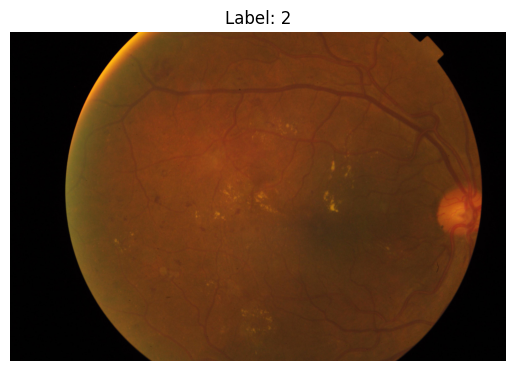

In [3]:
img_name = df.iloc[0]['id_code']
label = df.iloc[0]['diagnosis']

img = cv2.imread(f"data/train_images/{img_name}.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis('off')

In [5]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['diagnosis'],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 2929
Val: 733


In [6]:
import shutil

def copy_images(data, split):
    for _, row in data.iterrows():
        label = str(row['diagnosis'])
        img_name = row['id_code'] + ".png"

        src = f"data/train_images/{img_name}"
        dst = f"dataset/{split}/{label}"

        os.makedirs(dst, exist_ok=True)
        shutil.copy(src, f"{dst}/{img_name}")

copy_images(train_df, "train")
copy_images(val_df, "val")

print("Dataset prepared ✅")

Dataset prepared ✅


In [8]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    "dataset/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 2929 images belonging to 5 classes.
Found 733 images belonging to 5 classes.


In [9]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.4892 - loss: 1.3219 - val_accuracy: 0.4925 - val_loss: 1.3056
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.4927 - loss: 1.3023 - val_accuracy: 0.4925 - val_loss: 1.3002
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.4930 - loss: 1.3020 - val_accuracy: 0.4925 - val_loss: 1.2990
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.4930 - loss: 1.2996 - val_accuracy: 0.4925 - val_loss: 1.2988
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.4930 - loss: 1.2993 - val_accuracy: 0.4925 - val_loss: 1.2987
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.4930 - loss: 1.2980 - val_accuracy: 0.4925 - val_loss: 1.2957
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.4930 - loss: 1.2983 - val_accuracy: 0.4925 - val_loss: 1.2977
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.4930 - loss: 1.2969 - val_accu

In [11]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.2721 - loss: 1.7728 - val_accuracy: 0.4925 - val_loss: 1.3397
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.6367 - loss: 1.1496 - val_accuracy: 0.5812 - val_loss: 1.3053
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - accuracy: 0.6879 - loss: 0.9204 - val_accuracy: 0.6153 - val_loss: 1.2645
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.6999 - loss: 0.8301 - val_accuracy: 0.7080 - val_loss: 1.0536
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.7163 - loss: 0.7721 - val_accuracy: 0.6330 - val_loss: 1.0446
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.7361 - loss: 0.7317 - val_accuracy: 0.6726 - val_loss: 0.8510
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.7416 - loss: 0.7055 - val_accuracy: 0.6698 - val_loss: 0.9654
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.7357 - loss: 0.6904 - val_accu

In [12]:
model.save("model/elite_retina_model.h5")
print("Model saved ✅")

Model saved ✅


In [13]:
def predict_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    return np.argmax(pred)

print(predict_image("data/train_images/" + df.iloc[10]['id_code'] + ".png"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
0


In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 12,558,508 (47.91 MB)

 Trainable params: 4,172,161 (15.92 MB)

 Non-trainable params: 42,023 (164.16 KB)

 Optimizer params: 8,344,324 (31.83 MB)

In [16]:
for layer in model.layers[::-1]:
    try:
        if len(layer.output.shape) == 4:
            print(layer.name, layer.output.shape)
    except:
        pass

top_activation (None, 7, 7, 1280)
top_bn (None, 7, 7, 1280)
top_conv (None, 7, 7, 1280)
block7a_project_bn (None, 7, 7, 320)
block7a_project_conv (None, 7, 7, 320)
block7a_se_excite (None, 7, 7, 1152)
block7a_se_expand (None, 1, 1, 1152)
block7a_se_reduce (None, 1, 1, 48)
block7a_se_reshape (None, 1, 1, 1152)
block7a_activation (None, 7, 7, 1152)
block7a_bn (None, 7, 7, 1152)
block7a_dwconv (None, 7, 7, 1152)
block7a_expand_activation (None, 7, 7, 1152)
block7a_expand_bn (None, 7, 7, 1152)
block7a_expand_conv (None, 7, 7, 1152)
block6d_add (None, 7, 7, 192)
block6d_drop (None, 7, 7, 192)
block6d_project_bn (None, 7, 7, 192)
block6d_project_conv (None, 7, 7, 192)
block6d_se_excite (None, 7, 7, 1152)
block6d_se_expand (None, 1, 1, 1152)
block6d_se_reduce (None, 1, 1, 48)
block6d_se_reshape (None, 1, 1, 1152)
block6d_activation (None, 7, 7, 1152)
block6d_bn (None, 7, 7, 1152)
block6d_dwconv (None, 7, 7, 1152)
block6d_expand_activation (None, 7, 7, 1152)
block6d_expand_bn (None, 7, 7, 1152

In [19]:
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

def preprocess_image(image_path):
    img = cv2.imread(image_path)

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to model input size
    img = cv2.resize(img, (224, 224))

    # Apply EfficientNet preprocessing (IMPORTANT)
    img = preprocess_input(img)

    return img

In [20]:
img = preprocess_image("/Users/ektamishra/Desktop/dti_project_final copy/app/static/uploads/9e5ec293267c.png")
img_batch = np.expand_dims(img, axis=0)

preds = model.predict(img_batch)

print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[1. 0. 0. 0. 0.]]
